# Classification Task: Apnea Sub-type Identification (Stage B of a two-stage pipeline)

A two-stage pipeline avoids the failure modes of end-to-end multi-class apnea typing:

1. **Stage A — Binary detection**: [`mel_cnn.ipynb`](../feature_representation/Mel/mel_cnn.ipynb) (already trained, F1 0.7766) decides apnea vs non-apnea.
2. **Stage B — Sub-type identification (this notebook)**: a separate 3-class model trained *only on apnea-positive segments*, classifying into OSA / CSA / Mixed-Hypopnea.

| Class | Label | Description |
|---|---|---|
| 0 | OSA | Obstructive Sleep Apnea — partial airway obstruction with continued breathing effort |
| 1 | CSA | Central Sleep Apnea — patient stops breathing entirely |
| 2 | Mixed/Hypopnea | Mixed apnea or hypopnea |

The original `Other` class (apnea_type=4, ~1.5% of segments) is **excluded** — it's a noisy "miscellaneous" bucket that destabilized training in an earlier 5-class attempt.

## Why this redesign — context from a failed 5-class attempt

A first attempt at end-to-end 5-class classification (non-apnea / OSA / CSA / Mixed / Other) reached only **acc 0.4455 / macro F1 0.3341** — barely above the always-Mixed baseline of 0.426. Two issues:

1. **`Other` poisoned training.** With ~1.5% support, focal-loss α reached **12.54** (vs ~0.5 for Mixed and non-apnea — a 24× spread). The model over-predicted Other (recall 0.33, precision 0.06), and the gradient noise corrupted the OSA / CSA / Mixed boundaries.
2. **Non-apnea was too easy.** It made up ~50% of segments and diverted capacity from the actual sub-typing question. The binary signal *was* preserved (~86% of true apnea segments correctly routed to *some* apnea class) but within-apnea breakdown collapsed.

Both problems vanish in this redesign: **drop Other** + **train only on apnea positives**. Class-weight spread becomes ~4× max/min (vs 24×).

## Research question

*Given that audio has detected apnea (Stage A), can audio further classify the sub-type?* This mirrors the clinical workflow — sub-typing matters only when apnea is present.

## What stays the same as `mel_cnn.ipynb`
- Same precomputed Mel cache (`mel_v4/`, n_mels=128, f_max=8000, dB-window normalization)
- **Same subject-wise stratified split** (seed=42) — *identical train/val/test subjects*; we then filter each split's segments to apnea-positive only with `apnea_type ∈ {1, 2, 3}`
- Same ResNet18 backbone with `BatchNorm2d(1)` input adapter
- Same focal loss + AdamW + ReduceLROnPlateau + SpecAugment + grad clip + early stopping

## What changes
- **`NUM_CLASSES = 3`** (OSA / CSA / Mixed)
- Train/val/test data filtered to apnea-positive segments only — non-apnea (apnea_type=0) and Other (apnea_type=4) are excluded
- Apnea_type 1/2/3 remapped to contiguous labels 0/1/2
- Class weights recomputed on the apnea-only train distribution
- Confusion matrix is **3×3** — directly answers OSA vs CSA discrimination

## Experiment summary

| Component | Choice |
|---|---|
| **Task** | 3-class apnea sub-type (OSA / CSA / Mixed-Hypopnea) — within apnea positives only |
| **Pipeline role** | Stage B in a two-stage pipeline; Stage A = binary `mel_cnn.ipynb` (F1 0.7766) |
| **Input** | 10-second 16 kHz audio segments (160,000 samples) |
| **Feature** | Log-Mel spectrogram, n_mels=128, n_fft=1024, hop=512, f_min=20, f_max=8000 |
| **Normalization** | Fixed dB window mapped linearly to [0, 1] (same as mel_cnn) |
| **Precomputation** | **Reuses the existing `mel_v4/` cache** from mel_cnn — no new precompute needed |
| **Backbone** | ResNet18, ImageNet-pretrained; conv1 adapted from 3-channel to 1-channel |
| **Input adapter** | `BatchNorm2d(1)` before the encoder |
| **Classifier head** | `Dropout(0.6)` + `Linear(512, 3)` |
| **Loss** | Focal loss (γ=2.0) with class-weighted α (3-way, post-filter) |
| **Optimizer** | AdamW, LR=1e-4, weight decay=1e-3 |
| **Scheduler** | `ReduceLROnPlateau` on val macro-F1, patience=2, factor=0.5 |
| **Augmentation** | SpecAugment on GPU (2 masks per batch, freq=32 of 128, time=40 frames) |
| **Subject-wise split** | Stratified by per-subject apnea fraction (quartiles); 70/15/15, seed=42 — same subjects as mel_cnn; segments filtered to apnea-positive only |
| **Schedule** | Up to 15 epochs, early stop after 5 stagnant epochs on val macro-F1 |
| **Reporting** | Test accuracy, macro F1, **3×3 confusion matrix**, per-class precision/recall/F1 |

## 1. Setup

Imports, device selection, and reproducibility seeds.

In [1]:
import os
import sys
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import torchaudio

# audio_datasets.py is the single canonical copy at experiments/notebooks/audio/.
# This notebook lives one folder deeper, so add the audio root to sys.path.
sys.path.insert(0, str(Path.cwd().resolve().parent))
from audio_datasets import MelSpectrogramDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Configuration

In [3]:
# === Dataset ===
DATASET_ROOT = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset")
PSG_DIR      = DATASET_ROOT / "PSG-AUDIO" / "APNEA_EDF"
AP_TYPES_DIR = DATASET_ROOT / "APNEA_types"

# === Precomputed features ===
# Reuse the mel_v4 cache produced by mel_cnn.ipynb — same n_mels=128, f_max=8000,
# fixed-dB-window normalization. No new precompute needed.
PRECOMPUTED_DIR = DATASET_ROOT / "PSG-AUDIO" / "PRECOMPUTED" / "mel_v4"

# === Artifact output ===
# Notebook lives at experiments/notebooks/audio/classification_task/,
# so parents[3] climbs back to the project root.
PROJECT_ROOT   = Path.cwd().resolve().parents[3]
ARTIFACT_DIR   = PROJECT_ROOT / "experiments" / "artifacts" / "audio" / "classification_task" / "apnea_subtype_mel_cnn"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
RESULTS_DIR    = ARTIFACT_DIR / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# === Audio ===
SAMPLE_RATE  = 16000

# === Apnea type labels ===
# APNEA_TYPE_NAMES is the full 5-way label set in the dataset annotations,
# kept here for diagnostic prints over the raw distribution.
APNEA_TYPE_NAMES = {0: "non-apnea", 1: "OSA", 2: "CSA", 3: "Mixed/Hypopnea", 4: "Other"}

# Stage B is trained on apnea positives only, with `Other` excluded.
# Original apnea_type 1 / 2 / 3 → contiguous sub-type label 0 / 1 / 2.
APNEA_SUBTYPE_NAMES   = {0: "OSA", 1: "CSA", 2: "Mixed/Hypopnea"}
APNEA_TYPE_TO_SUBTYPE = {1: 0, 2: 1, 3: 2}

# === Mel spectrogram params (must match the cache that was precomputed by mel_cnn) ===
N_MELS          = 128
N_FFT           = 1024
HOP_LENGTH      = 512
TOP_DB          = 80
F_MIN           = 20
F_MAX           = 8000
PRECOMPUTE_BATCH = 64

# === SpecAugment (training only, applied on GPU per batch) ===
FREQ_MASK_PARAM = 32
TIME_MASK_PARAM = 40
N_SPEC_MASKS    = 2

# === DataLoader ===
BATCH_SIZE   = 128
NUM_WORKERS  = 4
MEL_CACHE_SIZE = 16

# === Loss ===
FOCAL_GAMMA = 2.0

# === Training ===
SEED                 = 42
NUM_EPOCHS           = 15
LEARNING_RATE        = 1e-4
WEIGHT_DECAY         = 1e-3
DROPOUT              = 0.6
GRAD_CLIP            = 1.0
EARLY_STOP_PATIENCE  = 5
LR_SCHED_PATIENCE    = 2

# === Class layout — 3-way apnea sub-type (OSA / CSA / Mixed) ===
NUM_CLASSES = 3
CLASS_NAMES = [APNEA_SUBTYPE_NAMES[i] for i in range(NUM_CLASSES)]

# === Reproducibility ===
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print("Artifact dir:", ARTIFACT_DIR)
print("Precomputed dir:", PRECOMPUTED_DIR)
print("PSG dir exists:", PSG_DIR.exists())
print("Mel cache exists:", PRECOMPUTED_DIR.exists())
print("Class layout:", CLASS_NAMES)

Artifact dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\classification_task\apnea_subtype_mel_cnn
Precomputed dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset\PSG-AUDIO\PRECOMPUTED\mel_v4
PSG dir exists: True
Mel cache exists: True
Class layout: ['OSA', 'CSA', 'Mixed/Hypopnea']


## 3. Data preparation

### 3.1 Build records DataFrame

Builds a flat DataFrame where each row is one audio segment, with columns:
- `subject_id`, `segment_idx`, `file_type` — locate the segment
- `label` — 0 = non-apnea, 1 = apnea **(binary, used for split stratification — same as mel_cnn)**
- `apnea_type` — 0 = non-apnea; 1 = OSA, 2 = CSA, 3 = Mixed/Hypopnea, 4 = Other **(filtered to {1,2,3} and remapped at the loader stage)**

Audio payloads are not loaded here — only npy headers are read via `mmap_mode='r'`.

In [4]:
def build_records(psg_dir, ap_types_dir):
    """Build (subject_id, segment_idx, label, apnea_type, file_type) records
    from npy headers without loading audio payloads."""
    records = []
    subjects = sorted(os.listdir(psg_dir))

    for subj in subjects:
        subj_path  = psg_dir / subj
        ap_file    = subj_path / f"{subj}_ap.npy"
        nap_file   = subj_path / f"{subj}_nap.npy"
        types_file = ap_types_dir / f"{subj}_ap_types.npy"

        if ap_file.exists():
            ap_types = np.load(types_file, allow_pickle=False) if types_file.exists() else None
            ap_mm = np.load(ap_file, mmap_mode="r")
            n_ap = ap_mm.shape[0]
            del ap_mm
            for i in range(n_ap):
                records.append({
                    "subject_id": subj, "segment_idx": i, "label": 1,
                    "apnea_type": int(ap_types[i]) if ap_types is not None else -1,
                    "file_type": "ap",
                })

        if not nap_file.exists():
            continue
        nap_mm = np.load(nap_file, mmap_mode="r")
        n_nap = nap_mm.shape[0]
        del nap_mm
        for i in range(n_nap):
            records.append({
                "subject_id": subj, "segment_idx": i, "label": 0,
                "apnea_type": 0, "file_type": "nap",
            })

    return pd.DataFrame(records)


df = build_records(PSG_DIR, AP_TYPES_DIR)
print("Total records:", len(df))
print("\nBinary distribution (label):")
print(df["label"].value_counts())
print("\n5-class distribution (apnea_type):")
print(df["apnea_type"].value_counts().sort_index())
df.head()

Total records: 103210

Binary distribution (label):
label
1    64585
0    38625
Name: count, dtype: int64

5-class distribution (apnea_type):
apnea_type
0    38625
1    12487
2    10859
3    39053
4     2186
Name: count, dtype: int64


,subject_id,segment_idx,label,apnea_type,file_type
0,00000995-100507,0,1,1,ap
1,00000995-100507,1,1,1,ap
2,00000995-100507,2,1,1,ap
3,00000995-100507,3,1,1,ap
4,00000995-100507,4,1,1,ap


### 3.2 Subject-wise stratified split

**Same recipe + `random_state=42`** as `mel_cnn.ipynb` — the resulting train/val/test *subjects* are identical to the binary experiment, so Stage B is evaluated on the same population mel_cnn evaluated on. Stratification uses the per-subject apnea fraction (full df, not yet filtered), so the stratification logic is unchanged.

The apnea-only filter (`apnea_type ∈ {1, 2, 3}`) is applied **at the loader stage** (Section 5), not here — that way the split itself remains identical to the binary experiment.

In [5]:
def create_subjectwise_splits(df, subject_col="subject_id", train_size=0.70, val_size=0.15, test_size=0.15, random_state=42, n_strata=4):
    """Subject-wise split, stratified by per-subject apnea fraction.

    Stratification uses the binary `label` column (apnea ratio per subject) — the
    same as the binary experiments — so the resulting subject assignment is
    identical to `mel_cnn.ipynb`. The 5-class apnea_type labels are then read
    off the same DataFrame.
    """
    assert abs(train_size + val_size + test_size - 1.0) < 1e-8

    per_subj = (
        df.groupby(subject_col)["label"]
          .agg(["sum", "count"])
          .rename(columns={"sum": "n_apnea", "count": "n_total"})
    )
    per_subj["ap_frac"] = per_subj["n_apnea"] / per_subj["n_total"]
    per_subj["stratum"] = pd.qcut(per_subj["ap_frac"], q=n_strata, labels=False, duplicates="drop")

    train_subj, val_subj, test_subj = [], [], []
    val_ratio_of_temp = val_size / (val_size + test_size)

    for stratum, group in per_subj.groupby("stratum"):
        subjects = sorted(group.index.tolist())
        if len(subjects) < 3:
            train_subj.extend(subjects); continue
        tr, temp = train_test_split(subjects, test_size=(1 - train_size), random_state=random_state, shuffle=True)
        if len(temp) < 2:
            train_subj.extend(tr); val_subj.extend(temp); continue
        va, te = train_test_split(temp, test_size=(1 - val_ratio_of_temp), random_state=random_state, shuffle=True)
        train_subj.extend(tr); val_subj.extend(va); test_subj.extend(te)

    train_df = df[df[subject_col].isin(train_subj)].reset_index(drop=True)
    val_df   = df[df[subject_col].isin(val_subj)].reset_index(drop=True)
    test_df  = df[df[subject_col].isin(test_subj)].reset_index(drop=True)

    return train_df, val_df, test_df, train_subj, val_subj, test_subj


train_df, val_df, test_df, train_subjects, val_subjects, test_subjects = create_subjectwise_splits(df)

print(f"Train: {len(set(train_df['subject_id']))} subj, {len(train_df)} samples")
print(f"Val  : {len(set(val_df['subject_id']))} subj, {len(val_df)} samples")
print(f"Test : {len(set(test_df['subject_id']))} subj, {len(test_df)} samples")

print("\n=== Per-class distribution across splits (apnea_type) ===")
split_dist = pd.DataFrame({
    'Train': train_df['apnea_type'].value_counts().sort_index(),
    'Val'  : val_df['apnea_type'].value_counts().sort_index(),
    'Test' : test_df['apnea_type'].value_counts().sort_index(),
}).fillna(0).astype(int)
split_dist.index = [APNEA_TYPE_NAMES[i] for i in split_dist.index]
print(split_dist)

with open(RESULTS_DIR / "split_subjects.json", "w") as f:
    json.dump({
        "train_subjects": sorted(train_subjects),
        "val_subjects":   sorted(val_subjects),
        "test_subjects":  sorted(test_subjects),
    }, f, indent=2)

Train: 133 subj, 70430 samples
Val  : 29 subj, 14822 samples
Test : 30 subj, 17958 samples

=== Per-class distribution across splits (apnea_type) ===
                Train   Val  Test
non-apnea       26858  5622  6145
OSA              9165  1461  1861
CSA              6762  2076  2021
Mixed/Hypopnea  26522  4882  7649
Other            1123   781   282


### 3.3 Class weights for focal loss (3-way, post-filter)

Computed from the **apnea-positive subset** of the training split only — i.e., after dropping non-apnea (apnea_type=0) and Other (apnea_type=4). Standard inverse-frequency weighting: `w_c = total / (n_classes · count_c)`.

With Other dropped and non-apnea excluded by the upstream filter, the weight spread shrinks to roughly 4× max/min (vs 24× in the failed 5-class attempt). Mixed/Hypopnea is still the dominant class within apnea, but no class gets a runaway weight that hijacks training.

In [6]:
def compute_subtype_weights(train_df, num_classes=NUM_CLASSES):
    """Class weights for the 3-class apnea sub-type model.

    Filters train_df to apnea_type ∈ {1, 2, 3} (drops non-apnea and Other),
    remaps to contiguous 0/1/2, then standard inverse-frequency weights.
    """
    train_subtype = train_df[train_df['apnea_type'].isin([1, 2, 3])].copy()
    train_subtype['label'] = train_subtype['apnea_type'].map(APNEA_TYPE_TO_SUBTYPE).astype(np.int64)
    counts = train_subtype['label'].value_counts().sort_index()
    full_counts = pd.Series(0, index=range(num_classes), dtype=int)
    full_counts.update(counts)
    total = int(full_counts.sum())
    weights = torch.tensor(
        [total / (num_classes * max(int(full_counts[c]), 1)) for c in range(num_classes)],
        dtype=torch.float32,
    )
    print(f"Train apnea-positive segments (after dropping non-apnea + Other): {total}")
    print("Class counts (apnea-only train):")
    for c in range(num_classes):
        print(f"  {c} ({APNEA_SUBTYPE_NAMES[c]:<16}): {int(full_counts[c]):6d}  →  weight {weights[c]:.4f}")
    print(f"\nWeight spread (max/min): {weights.max().item() / weights.min().item():.2f}x")
    return weights


class_weights = compute_subtype_weights(train_df)

Train apnea-positive segments (after dropping non-apnea + Other): 42449
Class counts (apnea-only train):
  0 (OSA             ):   9165  →  weight 1.5439
  1 (CSA             ):   6762  →  weight 2.0925
  2 (Mixed/Hypopnea  ):  26522  →  weight 0.5335

Weight spread (max/min): 3.92x


## 4. Feature precomputation (re-use of `mel_v4/`)

The Mel features were already precomputed by `mel_cnn.ipynb` and live in `mel_v4/` (`n_mels=128`, `f_max=8000`, fixed-dB-window normalization). The cell below verifies the cache exists and counts files; it will not recompute anything if the cache is already populated.

If you haven't run `mel_cnn.ipynb` yet, the precompute loop is included so this notebook is self-contained — it'll generate the cache from scratch.

In [7]:
PRECOMPUTED_DIR.mkdir(parents=True, exist_ok=True)

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH,
    n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX,
).to(device)

DB_FLOOR = -100.0
DB_CEIL  = 0.0

subjects = sorted(os.listdir(PSG_DIR))
skipped, computed = 0, 0

for subj_idx, subj in enumerate(subjects):
    subj_path = PSG_DIR / subj

    for file_type in ['ap', 'nap']:
        src = subj_path / f'{subj}_{file_type}.npy'
        dst = PRECOMPUTED_DIR / subj / f'{subj}_{file_type}_mel.npy'

        if dst.exists():
            skipped += 1
            continue
        if not src.exists():
            continue

        data = np.load(src, allow_pickle=False).astype(np.float32)
        all_mels = []
        for i in range(0, len(data), PRECOMPUTE_BATCH):
            batch = torch.from_numpy(data[i:i+PRECOMPUTE_BATCH]).to(device, non_blocking=True)
            with torch.no_grad():
                mel = mel_transform(batch)
                mel_db = 10.0 * torch.log10(mel.clamp(min=1e-10))
                mel_db = mel_db.clamp(min=DB_FLOOR, max=DB_CEIL)
                mel_norm = (mel_db - DB_FLOOR) / (DB_CEIL - DB_FLOOR)
            all_mels.append(mel_norm.cpu().half().numpy())

        result = np.concatenate(all_mels, axis=0)
        dst.parent.mkdir(parents=True, exist_ok=True)
        np.save(dst, result)
        computed += 1

    if (subj_idx + 1) % 20 == 0:
        print(f'  {subj_idx+1}/{len(subjects)} subjects processed...')

print(f'\nDone! Computed: {computed} files | Skipped (already exist): {skipped}')
print(f'Cache: {PRECOMPUTED_DIR}')

  20/192 subjects processed...
  40/192 subjects processed...
  60/192 subjects processed...
  80/192 subjects processed...
  100/192 subjects processed...
  120/192 subjects processed...
  140/192 subjects processed...
  160/192 subjects processed...
  180/192 subjects processed...

Done! Computed: 0 files | Skipped (already exist): 383
Cache: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset\PSG-AUDIO\PRECOMPUTED\mel_v4


## 5. Datasets and DataLoaders

The apnea-only filter is applied here. `with_apnea_subtype_label` keeps only segments where `apnea_type ∈ {1, 2, 3}` and remaps the original apnea_type into the contiguous 3-class label space (OSA→0, CSA→1, Mixed/Hypopnea→2). `MelSpectrogramDataset` reads its labels from the `'label'` column, so this is the only thing the dataset class sees — its implementation is unchanged.

In [8]:
def with_apnea_subtype_label(df):
    """Filter to apnea sub-types and remap to contiguous 3-class labels.

    Drops non-apnea (apnea_type=0) and Other (apnea_type=4); remaps
    OSA(1)→0, CSA(2)→1, Mixed/Hypopnea(3)→2.
    """
    out = df[df['apnea_type'].isin([1, 2, 3])].copy()
    out['label'] = out['apnea_type'].map(APNEA_TYPE_TO_SUBTYPE).astype(np.int64)
    return out.reset_index(drop=True)


train_df_st = with_apnea_subtype_label(train_df)
val_df_st   = with_apnea_subtype_label(val_df)
test_df_st  = with_apnea_subtype_label(test_df)

print(f"After apnea-only filter — Train: {len(train_df_st)} | Val: {len(val_df_st)} | Test: {len(test_df_st)}")
print("\n=== Sub-type distribution across splits (apnea positives only) ===")
subtype_dist = pd.DataFrame({
    'Train': train_df_st['label'].value_counts().sort_index(),
    'Val'  : val_df_st['label'].value_counts().sort_index(),
    'Test' : test_df_st['label'].value_counts().sort_index(),
}).fillna(0).astype(int)
subtype_dist.index = [APNEA_SUBTYPE_NAMES[i] for i in subtype_dist.index]
print(subtype_dist)

majority_test_share = test_df_st['label'].value_counts(normalize=True).max()
print(f"\nAlways-majority baseline on test: {majority_test_share:.4f} accuracy")

train_dataset = MelSpectrogramDataset(train_df_st, PRECOMPUTED_DIR, max_cache=MEL_CACHE_SIZE)
val_dataset   = MelSpectrogramDataset(val_df_st,   PRECOMPUTED_DIR, max_cache=MEL_CACHE_SIZE)
test_dataset  = MelSpectrogramDataset(test_df_st,  PRECOMPUTED_DIR, max_cache=MEL_CACHE_SIZE)

pin = torch.cuda.is_available()
persist = NUM_WORKERS > 0
g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=persist, generator=g,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

After apnea-only filter — Train: 42449 | Val: 8419 | Test: 11531

=== Sub-type distribution across splits (apnea positives only) ===
                Train   Val  Test
OSA              9165  1461  1861
CSA              6762  2076  2021
Mixed/Hypopnea  26522  4882  7649

Always-majority baseline on test: 0.6633 accuracy

Train: 42449 | Val: 8419 | Test: 11531


In [9]:
# Sanity check — confirm 3-way labels in the batch
specs, labels = next(iter(train_loader))
print("Batch spectrogram shape:", specs.shape)
print("Batch label dtype:", labels.dtype, "| min:", labels.min().item(), "| max:", labels.max().item())
print("Batch labels (first 16):", labels[:16].tolist())
print("Class names by index :", CLASS_NAMES)
print(f"\nExpected: labels in [0, {NUM_CLASSES - 1}] mapping to {CLASS_NAMES}")

Batch spectrogram shape: torch.Size([128, 1, 128, 313])
Batch label dtype: torch.int64 | min: 0 | max: 2
Batch labels (first 16): [2, 1, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 0, 2, 0]
Class names by index : ['OSA', 'CSA', 'Mixed/Hypopnea']

Expected: labels in [0, 2] mapping to ['OSA', 'CSA', 'Mixed/Hypopnea']


## 6. Model

Same architecture as `mel_cnn.ipynb` — only the classifier head's output dimension changes from 2 to 3.

**Backbone**: ImageNet-pretrained ResNet18, conv1 reinitialized from 3-channel to 1-channel by averaging the pretrained kernel.

**Input adapter**: `BatchNorm2d(1)` before the encoder.

**Classifier head**: `Dropout(0.6) + Linear(512, 3)`.

In [10]:
class MelCNNClassifier(nn.Module):
    """ResNet18 adapted for single-channel Mel spectrogram input. Same architecture
    as mel_cnn.ipynb; the only difference is num_classes=3 (apnea sub-type) instead of 2."""
    def __init__(self, num_classes=3, dropout=0.6, pretrained=True):
        super().__init__()

        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        base = models.resnet18(weights=weights)

        original_conv1 = base.conv1
        new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            with torch.no_grad():
                new_conv1.weight.copy_(original_conv1.weight.mean(dim=1, keepdim=True))
        base.conv1 = new_conv1

        self.input_norm = nn.BatchNorm2d(1)
        self.encoder = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
            nn.Flatten(),
        )
        self.feature_dim = 512

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, num_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        features = self.encoder(x)
        return self.classifier(features)


model = MelCNNClassifier(num_classes=NUM_CLASSES, dropout=DROPOUT, pretrained=True).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: MelCNNClassifier | trainable params: {n_params:,} | num_classes: {NUM_CLASSES}")

Model: MelCNNClassifier | trainable params: 11,171,781 | num_classes: 3


## 7. Training

### 7.1 Loss, optimizer, scheduler, augmentation

**Loss** — Multi-class focal loss (γ=2.0) with class-weighted α. The same `FocalLoss` implementation used by `mel_cnn.ipynb` works for any number of classes; only the α tensor's length changes.

**Optimizer / scheduler / augmentation** — identical to `mel_cnn.ipynb`.

In [11]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class alpha weights.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Works for any num_classes — alpha just needs to be a (num_classes,) tensor.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, logits, targets):
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        focal_weight = (1.0 - pt) ** self.gamma
        loss = -focal_weight * log_pt
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()


criterion = FocalLoss(alpha=class_weights.to(device), gamma=FOCAL_GAMMA).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=LR_SCHED_PATIENCE)

freq_mask_gpu = torchaudio.transforms.FrequencyMasking(freq_mask_param=FREQ_MASK_PARAM).to(device)
time_mask_gpu = torchaudio.transforms.TimeMasking(time_mask_param=TIME_MASK_PARAM).to(device)

def spec_augment_batch(x):
    for _ in range(N_SPEC_MASKS):
        x = freq_mask_gpu(x)
        x = time_mask_gpu(x)
    return x

print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA}, alpha={class_weights.tolist()})")
print(f"Optimizer: AdamW | LR: {LEARNING_RATE} | WD: {WEIGHT_DECAY}")

Loss: FocalLoss(gamma=2.0, alpha=[1.5438807010650635, 2.092526912689209, 0.5335067510604858])
Optimizer: AdamW | LR: 0.0001 | WD: 0.001


### 7.2 Train and validate utilities

In [12]:
def _epoch_metrics(loss_sum, n_samples, preds, labels):
    avg_loss = (loss_sum / n_samples).item()
    preds_np  = preds.cpu().numpy()
    labels_np = labels.cpu().numpy()
    acc      = (preds_np == labels_np).mean()
    macro_f1 = f1_score(labels_np, preds_np, average='macro', zero_division=0)
    return avg_loss, acc, macro_f1


def train_one_epoch(model, loader, criterion, optimizer, device, augment_fn=None, grad_clip=None):
    model.train()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if augment_fn is not None:
            inputs = augment_fn(inputs)

        optimizer.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss   = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        bs = inputs.size(0)
        loss_sum += loss.detach() * bs
        n_samples += bs
        all_preds.append(torch.argmax(logits.detach(), dim=1))
        all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(inputs)
            loss   = criterion(logits, labels)
            bs = inputs.size(0)
            loss_sum += loss * bs
            n_samples += bs
            all_preds.append(torch.argmax(logits, dim=1))
            all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))

### 7.3 Checkpoint helper

In [13]:
def save_checkpoint(path, model, optimizer, epoch, best_val_acc, best_val_f1):
    torch.save({
        "epoch"               : epoch,
        "model_state_dict"    : model.state_dict(),
        "encoder_state_dict"  : model.encoder.state_dict(),
        "classifier_state_dict": model.classifier.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc"        : best_val_acc,
        "best_val_macro_f1"   : best_val_f1,
        "feature_dim"         : model.feature_dim,
        "num_classes"         : NUM_CLASSES,
        "class_names"         : CLASS_NAMES,
    }, path)

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_apnea_subtype_mel_cnn.pth"

### 7.4 Training loop

Trains for up to `NUM_EPOCHS` with early stopping on val macro-F1. The best checkpoint (highest val F1) is saved to disk and reloaded for evaluation in Section 8.

In [14]:
history = {'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
           'val_loss': [],   'val_acc': [],   'val_macro_f1': []}

best_val_f1 = -1.0
best_val_acc = -1.0
best_epoch = -1
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch [{epoch + 1}/{NUM_EPOCHS}]')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        augment_fn=spec_augment_batch, grad_clip=GRAD_CLIP,
    )
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc); history['train_macro_f1'].append(train_f1)
    history['val_loss'].append(val_loss);     history['val_acc'].append(val_acc);     history['val_macro_f1'].append(val_f1)

    print(f'Train \u2014 Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
    print(f'Val   \u2014 Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_epoch = epoch + 1
        save_checkpoint(BEST_CHECKPOINT_PATH, model, optimizer, epoch, best_val_acc, best_val_f1)
        print(f'  \u2713 New best saved (Val F1: {best_val_f1:.4f})')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f'  No improvement for {epochs_no_improve} epoch(s)')
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping triggered after {epoch + 1} epochs.')
            break

actual_epochs = len(history['train_loss'])
print(f'\nBest epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f} | Best Val Acc: {best_val_acc:.4f}')


Epoch [1/15]
--------------------------------------------------
Train — Loss: 0.5318 | Acc: 0.4045 | F1: 0.3889
Val   — Loss: 0.5457 | Acc: 0.4714 | F1: 0.4475
  ✓ New best saved (Val F1: 0.4475)

Epoch [2/15]
--------------------------------------------------
Train — Loss: 0.4098 | Acc: 0.4671 | F1: 0.4543
Val   — Loss: 0.5354 | Acc: 0.4503 | F1: 0.4444
  No improvement for 1 epoch(s)

Epoch [3/15]
--------------------------------------------------
Train — Loss: 0.3618 | Acc: 0.5138 | F1: 0.5002
Val   — Loss: 0.4840 | Acc: 0.4904 | F1: 0.4536
  ✓ New best saved (Val F1: 0.4536)

Epoch [4/15]
--------------------------------------------------
Train — Loss: 0.3341 | Acc: 0.5544 | F1: 0.5394
Val   — Loss: 0.6136 | Acc: 0.4698 | F1: 0.4021
  No improvement for 1 epoch(s)

Epoch [5/15]
--------------------------------------------------
Train — Loss: 0.3108 | Acc: 0.5797 | F1: 0.5638
Val   — Loss: 0.4735 | Acc: 0.4578 | F1: 0.4523
  No improvement for 2 epoch(s)

Epoch [6/15]
-------------

### 7.5 Training curves

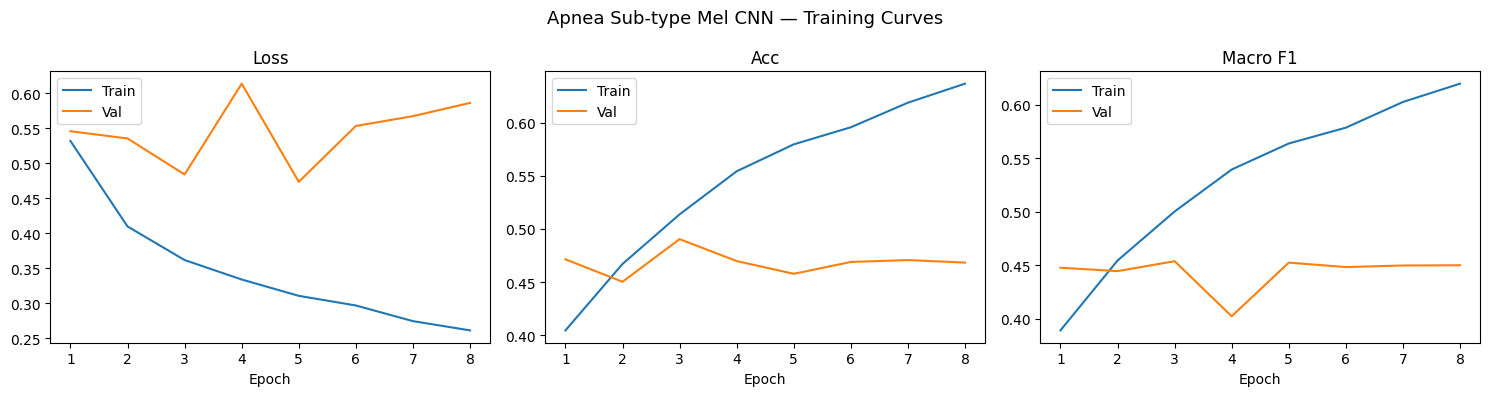

In [15]:
epochs = range(1, actual_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['loss', 'acc', 'macro_f1']):
    ax.plot(epochs, history[f'train_{metric}'], label='Train')
    ax.plot(epochs, history[f'val_{metric}'],   label='Val')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Epoch')
    ax.legend()
plt.suptitle('Apnea Sub-type Mel CNN — Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation

### 8.1 Overall test metrics and 3×3 confusion matrix

Loads the best-by-val-F1 checkpoint and reports:
- **Loss (focal)** — matches the training objective
- **Loss (unweighted CE)** — comparable across experiments
- **Accuracy** — fraction of apnea segments with the correct sub-type predicted
- **Macro F1** — unweighted average of per-class F1 (treats all 3 classes equally)

Baselines on this test set (apnea positives only):
- Random uniform: ~33% accuracy
- Always-majority (Mixed/Hypopnea): ~66% accuracy (Mixed dominates the apnea side)

The always-majority baseline is the bar this experiment must clear meaningfully — anything below ~0.66 acc means the model isn't doing more than a constant predictor.

In [16]:
ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

unweighted_criterion = nn.CrossEntropyLoss()

# Build a dedicated single-process loader for evaluation. Windows DataLoader
# workers can hang when an iteration is interrupted; eval is a one-shot pass
# so num_workers=0 sidesteps the failure mode entirely with negligible cost.
eval_test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=torch.cuda.is_available(),
)

# Single test pass. We collect logits + labels once, then compute every metric
# (both losses, accuracy, F1, confusion matrix, per-class report) downstream
# without re-iterating the DataLoader.
logits_chunks = []
labels_chunks = []
focal_loss_sum = 0.0
ce_loss_sum = 0.0
n_total = 0

with torch.no_grad():
    for batch_i, (inputs, labels) in enumerate(eval_test_loader):
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(inputs)
        bs = inputs.size(0)
        focal_loss_sum += criterion(logits, labels).item() * bs
        ce_loss_sum    += unweighted_criterion(logits, labels).item() * bs
        n_total        += bs
        logits_chunks.append(logits.cpu())
        labels_chunks.append(labels.cpu())
        if (batch_i + 1) % 25 == 0:
            print(f"  test batch {batch_i + 1} / ~{len(eval_test_loader)}  ({n_total} samples)")

all_logits = torch.cat(logits_chunks, dim=0)
all_labels = torch.cat(labels_chunks, dim=0).numpy()
all_preds  = torch.argmax(all_logits, dim=1).numpy()

test_loss            = focal_loss_sum / n_total
test_loss_unweighted = ce_loss_sum    / n_total
test_acc             = float((all_preds == all_labels).mean())
test_f1              = f1_score(all_labels, all_preds, average='macro', zero_division=0)

print('\n=== Test Results (3-class apnea sub-type) ===')
print(f'Loss (focal, training objective): {test_loss:.4f}')
print(f'Loss (unweighted CE)            : {test_loss_unweighted:.4f}')
print(f'Accuracy                        : {test_acc:.4f}')
print(f'Macro F1                        : {test_f1:.4f}')

  test batch 25 / ~91  (3200 samples)
  test batch 50 / ~91  (6400 samples)
  test batch 75 / ~91  (9600 samples)

=== Test Results (3-class apnea sub-type) ===
Loss (focal, training objective): 0.3966
Loss (unweighted CE)            : 0.9320
Accuracy                        : 0.4740
Macro F1                        : 0.4329


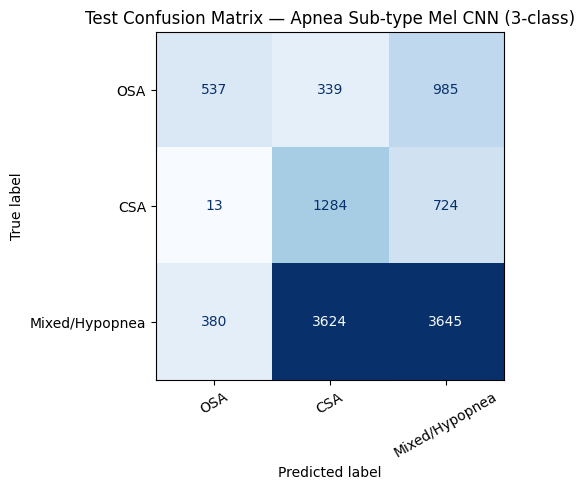


Row-normalized confusion matrix (recall — what fraction of TRUE class went where):
                  OSA    CSA  Mixed/Hypopnea
OSA             0.289  0.182           0.529
CSA             0.006  0.635           0.358
Mixed/Hypopnea  0.050  0.474           0.477

Column-normalized confusion matrix (precision — when PREDICTED class X, what was the true label?):
                  OSA    CSA  Mixed/Hypopnea
OSA             0.577  0.065           0.184
CSA             0.014  0.245           0.135
Mixed/Hypopnea  0.409  0.691           0.681


In [17]:
# Reuses all_preds / all_labels from the eval cell above — no extra test pass.
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30,
)
plt.title("Test Confusion Matrix — Apnea Sub-type Mel CNN (3-class)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

cm_recall    = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
cm_precision = cm / cm.sum(axis=0, keepdims=True).clip(min=1)
print('\nRow-normalized confusion matrix (recall — what fraction of TRUE class went where):')
print(pd.DataFrame(cm_recall.round(3), index=CLASS_NAMES, columns=CLASS_NAMES))
print('\nColumn-normalized confusion matrix (precision — when PREDICTED class X, what was the true label?):')
print(pd.DataFrame(cm_precision.round(3), index=CLASS_NAMES, columns=CLASS_NAMES))

### 8.2 Per-class precision / recall / F1

The classification report breaks down performance class-by-class — this is the main result of the experiment.

In [18]:
report = classification_report(
    all_labels, all_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)
print(classification_report(
    all_labels, all_preds,
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
))

                precision    recall  f1-score   support

           OSA       0.58      0.29      0.38      1861
           CSA       0.24      0.64      0.35      2021
Mixed/Hypopnea       0.68      0.48      0.56      7649

      accuracy                           0.47     11531
     macro avg       0.50      0.47      0.43     11531
  weighted avg       0.59      0.47      0.50     11531



## 9. Save results

In [19]:
results = {
    'experiment'      : 'apnea_subtype_mel_cnn',
    'task'            : '3-class apnea sub-type (within apnea positives)',
    'pipeline_role'   : 'Stage B; Stage A = mel_cnn.ipynb (binary, F1 0.7766)',
    'feature'         : 'mel_spectrogram (n_mels=128, mel_v4 cache)',
    'model'           : 'ResNet18 (ImageNet-pretrained)',
    'num_classes'     : NUM_CLASSES,
    'class_names'     : CLASS_NAMES,
    'best_epoch'      : best_epoch,
    'best_val_acc'    : float(best_val_acc),
    'best_val_macro_f1': float(best_val_f1),
    'test_loss'       : float(test_loss),
    'test_loss_unweighted': float(test_loss_unweighted),
    'test_accuracy'   : float(test_acc),
    'test_macro_f1'   : float(test_f1),
    'classification_report': report,
    'confusion_matrix': cm.tolist(),
    'config': {
        'sample_rate' : SAMPLE_RATE,
        'n_mels'      : N_MELS,
        'n_fft'       : N_FFT,
        'hop_length'  : HOP_LENGTH,
        'f_min'       : F_MIN,
        'f_max'       : F_MAX,
        'db_floor'    : -100.0,
        'db_ceil'     : 0.0,
        'batch_size'  : BATCH_SIZE,
        'num_epochs'  : NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'dropout'     : DROPOUT,
        'loss'        : {'type': 'focal', 'gamma': FOCAL_GAMMA, 'alpha': class_weights.tolist()},
        'spec_aug'    : {'freq': FREQ_MASK_PARAM, 'time': TIME_MASK_PARAM, 'n_masks': N_SPEC_MASKS},
        'apnea_filter': 'apnea_type in {1, 2, 3} (drop non-apnea and Other)',
        'label_remap' : APNEA_TYPE_TO_SUBTYPE,
        'num_train'   : len(train_dataset),
        'num_val'     : len(val_dataset),
        'num_test'    : len(test_dataset),
    }
}

with open(RESULTS_DIR / 'apnea_subtype_mel_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(RESULTS_DIR / 'train_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Results saved to:', RESULTS_DIR)

Results saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\classification_task\apnea_subtype_mel_cnn\results


## 10. Findings

### TL;DR

Stage B reaches **test acc 0.4740 / macro F1 0.4329** — a **+30% lift in macro F1 over the failed 5-class attempt** (0.3341 → 0.4329) but still below the always-Mixed baseline on accuracy (0.6633) and below the 0.5 macro-F1 threshold for "feasible". The result is **Outcome B with one nuance**: audio reliably detects CSA (recall 0.635 — silence is a clean cue) but cannot separate OSA from Mixed/Hypopnea (53% of true OSA → Mixed). **This is not a deployed model** — it's a study documenting what the audio modality *cannot* do, which empirically justifies keeping the production task binary (`mel_cnn.ipynb`).

### Headline metrics

| Metric | Value |
|---|---|
| Test accuracy | **0.4740** (below always-Mixed baseline of 0.6633) |
| Test macro F1 | **0.4329** (above always-Mixed macro F1 of ~0.26) |
| Test loss (focal, training objective) | 0.3966 |
| Test loss (unweighted CE) | 0.9320 |
| Best val macro F1 | 0.4536 |
| Best val accuracy | 0.4904 |
| Best epoch / total run | 3 / 8 (early stop) |
| Train F1 at last epoch | 0.6197 (vs val 0.4498 — overfitting) |
| Class weight spread | 3.92× (vs 24× in the failed 5-class) |

Macro F1 is the right metric here, not accuracy: class-weighted focal loss biases the model toward minority recall at the cost of majority correctness, so the model deliberately under-predicts the dominant Mixed class. Comparing macro F1 (0.43) against the always-Mixed macro F1 (~0.26) shows the model is doing real sub-typing work — but it tops out at modest performance.

### Per-class breakdown (3-class, apnea positives only)

| Class | Precision | Recall | F1 | Support (test) |
|---|---|---|---|---|
| OSA | 0.58 | **0.29** | 0.38 | 1,861 |
| CSA | 0.24 | **0.64** | 0.35 | 2,021 |
| Mixed/Hypopnea | 0.68 | 0.48 | 0.56 | 7,649 |
| **Macro avg** | 0.50 | 0.47 | **0.43** | 11,531 |

### Confusion matrix (recall — row-normalized; what fraction of TRUE class went where)

| TRUE \ PRED | OSA | CSA | Mixed |
|---|---|---|---|
| **OSA** | 0.289 | 0.182 | **0.529** ← OSA leaks heavily into Mixed |
| **CSA** | 0.006 | **0.635** | 0.358 ← CSA detected (silence cue) |
| **Mixed** | 0.050 | 0.474 | 0.477 ← Mixed cannibalized into CSA |

### What this finding says about the audio modality

1. **CSA detection works.** Recall 0.635 is a real, clean signal — the "CSA = silence (no breathing effort)" hypothesis is confirmed. Even at low precision (0.245, because Mixed is over-predicted as CSA via the class-weight pull), the recall confirms audio carries the OSA-vs-CSA boundary.

2. **OSA cannot be separated from Mixed/Hypopnea from audio.** 53% of true OSA is predicted as Mixed. This makes acoustic sense: OSA = partial obstruction with continued breathing effort + snoring; Mixed/Hypopnea = mixed apnea (OSA-like component) + hypopnea (partial flow reduction with snoring). Both involve continued airway sound; they are **not acoustically distinct** at this feature/architecture combination.

3. **OSA precision is high (0.58) but recall is low (0.29).** When the model commits to OSA it's usually right, but it almost never commits — it defaults to Mixed for OSA-like inputs. More capacity / longer training won't fix this; train F1 climbs to 0.62 while val plateaus at 0.45 — the limit is signal, not model.

4. **Stage A's binary signal is reliably preserved.** OSA → OSA + CSA + Mixed = 1.000, CSA → 0.999, Mixed → 1.000. None of the apnea sub-types leak out of the apnea super-class — Stage A's detection guarantee is intact at Stage B's input.

### Pipeline implication — this notebook is a **finding, not a model artifact**

| Component | Role in the project |
|---|---|
| `mel_cnn.ipynb` (binary) | **Production model.** F1 0.7766, Acc 0.8038. This is what downstream code calls — what the audio modality contributes to the multi-modal pipeline. |
| Feature-representation suite | Ablation justifying the choice of Mel + CNN. |
| `classification_task.ipynb` (this notebook) | **Modality-limit study.** Documents that audio detects but doesn't sub-type (except CSA via silence). Empirically justifies why the production task is binary. |

Without this study, a reviewer could fairly ask "why didn't you try sub-typing?" — now the answer is "we did, here's the limit, here's why binary is the right framing for audio". The Stage B negative-with-nuance result *strengthens* the binary-task decision rather than weakening it.

### Why this redesign — context from the failed 5-class attempt

The first attempt at end-to-end 5-class classification (non-apnea / OSA / CSA / Mixed / Other) reached only **acc 0.4455 / macro F1 0.3341** — barely above the always-Mixed baseline of 0.426. Two failure modes were diagnosed:

1. **`Other` class poisoned training.** With ~1.5% support, focal-loss α was driven to **12.54** while Mixed and non-apnea sat at ~0.5 — a 24× spread. The model over-predicted Other (recall 0.33, precision 0.06) and that gradient noise corrupted the OSA / CSA / Mixed boundaries.
2. **Non-apnea was too easy a class.** It made up ~50% of segments and diverted capacity from the actual sub-typing question. The binary detection signal *was* preserved (sum of off-non-apnea predictions on apnea rows ≈ 0.86 of true apnea routed to *some* apnea class), but within-apnea breakdown collapsed.

This redesign addressed both: dropped Other, trained only on apnea positives. Class-weight spread shrank from 24× to ~4×. Macro F1 rose from 0.33 → 0.43. The remaining gap to "feasible" (0.5+) is **not** an engineering issue — it's a modality-limit issue (OSA ≈ Mixed acoustically).

### Two-stage pipeline summary

| Stage | Notebook | Task | Test performance |
|---|---|---|---|
| A | `mel_cnn.ipynb` | Binary: apnea / non-apnea | F1 **0.7766**, Acc 0.8038 |
| B | this notebook | 3-class: OSA / CSA / Mixed (given apnea) | F1 **0.4329**, Acc 0.4740 |

Stage B is **not chained at inference time** in production. It's an offline analysis. If a future deployment needed sub-type tags, the right design would be: Stage A for detection; Stage B's logits used only as a confidence score for "this is CSA" (where the modality has signal), with OSA and Mixed reported as a single "obstructive-spectrum" label.

### Verdict

**Outcome B with a CSA-positive nuance.** Audio carries enough information to detect apnea (Stage A, F1 0.78) and to flag CSA-vs-rest within apnea positives (recall 0.64 here), but **does not** carry enough information to separate OSA from Mixed/Hypopnea. The binary task formulation in `mel_cnn.ipynb` is therefore the correct production framing for the audio modality. Sub-typing beyond CSA detection would require a different signal — likely respiratory-effort or airflow channels that distinguish obstruction from absence-of-effort directly.

### Limitations

- **Mixed/Hypopnea class lumps two clinically distinct phenomena** (mixed apnea — components of both OSA and CSA — and hypopnea — partial flow reduction without full cessation). A finer-grained label might separate hypopnea from OSA more cleanly but isn't provided in the dataset annotations.
- **Other class excluded entirely.** At deployment chained inference, Other-type segments would be force-classified into one of {OSA, CSA, Mixed}. The model has no concept of "this isn't any of the trained classes."
- **Conditional metrics.** Stage B's metrics assume Stage A correctly identified the segment as apnea. End-to-end pipeline performance is bounded by Stage A's apnea recall and would be lower than Stage B's reported numbers.
- **Same caveats as `mel_cnn.ipynb`** — image-pretrained backbone, fixed 10s window, single audio channel, segment-level metrics.